# 03c — Atención temporal sobre representaciones wav2vec multicapa

Este notebook define el mejor modelo SSL antes de incorporar una rama espectral. Compara cuatro configuraciones bajo los **mismos outer folds persistidos**:

```text
average_mean_std
learned_layers_mean_std
average_attention_statistics
learned_layers_attention_statistics
```

La referencia principal integra capas de forma uniforme y conserva media y desvío temporal. Los dos modelos nuevos evalúan si una ponderación temporal aprendida agrega información y si conviene aprender simultáneamente los pesos entre capas.

El encoder wav2vec permanece congelado. Los test finales no se cargan ni se utilizan.

## 1. Configuración y artefactos

Los bloques costosos se activan por separado. La ejecución recomendada es:

```text
1. RUN_FEATURE_EXTRACTION
2. RUN_STATIC_POOLING
3. RUN_LAYER_MIXTURE
4. RUN_AVERAGE_ATTENTION
5. RUN_LEARNED_LAYER_ATTENTION
```

La extracción genera un tensor multicapa por audio con forma `[capas, frames, hidden]`. Los modelos aprendidos realizan early stopping únicamente dentro de outer train.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.contracts import (
    PROTOCOL_INDEPENDENT,
    TARGET_EMOTION_ORIGINAL,
    TARGET_EMOTION_ORIGINAL_EVAL_QUADRANT,
    TARGET_EMOTION_QUADRANT,
)
from src.experiments.temporal_representation import (
    load_attention_weights,
    run_average_attention_cv,
    run_layer_mixture_grid,
    run_learned_layer_attention_cv,
    run_static_pooling_grid,
    save_attention_weights,
)
from src.features.wav2vec_temporal import (
    extract_or_load_temporal_features,
    load_layer_statistics,
)
from src.utils.config import get_config, resolve_path
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

cfg = get_config()
set_global_seed(int(cfg.seed))

metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STATS_PATH = resolve_path(cfg.temporal_representation.layer_statistics_path)
SEQUENCES_DIR = resolve_path(cfg.temporal_representation.sequences_dir)
MULTILAYER_SEQUENCES_DIR = resolve_path(
    cfg.temporal_representation.multilayer_sequences_dir
)

RESULTS_PATH = REPORTS_DIR / "temporal_representation_results.csv"
OOF_PATH = REPORTS_DIR / "temporal_oof_predictions.csv"
LAYER_WEIGHTS_PATH = REPORTS_DIR / "layer_mixture_weights.csv"
ATTENTION_SEED_PATH = REPORTS_DIR / "attention_seed_results.csv"
ATTENTION_DIAGNOSTICS_PATH = REPORTS_DIR / "attention_diagnostics.csv"
ATTENTION_WEIGHTS_PATH = REPORTS_DIR / "attention_weights_multilayer.npz"

RUN_FEATURE_EXTRACTION = True
RUN_STATIC_POOLING = True
RUN_LAYER_MIXTURE = True
RUN_AVERAGE_ATTENTION = True
RUN_LEARNED_LAYER_ATTENTION = True

RUN_SECONDARY_TARGETS = False

TARGETS = [TARGET_EMOTION_ORIGINAL]
if RUN_SECONDARY_TARGETS:
    TARGETS += [
        TARGET_EMOTION_QUADRANT,
        TARGET_EMOTION_ORIGINAL_EVAL_QUADRANT,
    ]

PROTOCOLS = [PROTOCOL_INDEPENDENT]

ACTIVE_CONFIGURATIONS = [
    "average_mean_std",
    "learned_layers_mean_std",
    "average_attention_statistics",
    "learned_layers_attention_statistics",
]

print(f"Metadata: {len(metadata)} audios")
print(f"Targets: {TARGETS}")
print(f"Protocolos: {PROTOCOLS}")
print(f"Dispositivo temporal: {'configurado por PyTorch en src'}")

Metadata: 1440 audios
Targets: ['emotion_original']
Protocolos: ['speaker_independent']
Dispositivo temporal: configurado por PyTorch en src


In [2]:
def load_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def upsert_rows(
    existing: pd.DataFrame,
    new: pd.DataFrame,
    keys: list[str],
) -> pd.DataFrame:
    if existing.empty:
        return new.copy().reset_index(drop=True)
    if new.empty:
        return existing.copy().reset_index(drop=True)

    missing = set(keys) - set(existing.columns) | set(keys) - set(new.columns)
    if missing:
        raise KeyError(f"Faltan claves para consolidar resultados: {sorted(missing)}")

    old_index = pd.MultiIndex.from_frame(existing[keys].fillna("<NA>"))
    new_index = pd.MultiIndex.from_frame(new[keys].fillna("<NA>"))
    retained = existing.loc[~old_index.isin(new_index)]
    return pd.concat([retained, new], ignore_index=True, sort=False)


def save_results(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)


RESULT_KEYS = [
    "representation",
    "protocol",
    "target",
    "model",
    "refinement",
    "fold",
    "seed",
    "result_type",
]
PREDICTION_KEYS = [
    "file_id",
    "protocol",
    "target",
    "model",
    "refinement",
    "fold",
]
LAYER_WEIGHT_KEYS = [
    "configuration",
    "protocol",
    "target",
    "fold",
    "seed",
    "layer",
]
DIAGNOSTIC_KEYS = [
    "file_id",
    "configuration",
    "protocol",
    "target",
    "fold",
    "seed",
]

results = load_csv(RESULTS_PATH)
oof_predictions = load_csv(OOF_PATH)
layer_weights = load_csv(LAYER_WEIGHTS_PATH)
attention_seed_results = load_csv(ATTENTION_SEED_PATH)
attention_diagnostics = load_csv(ATTENTION_DIAGNOSTICS_PATH)
attention_weight_map = load_attention_weights(ATTENTION_WEIGHTS_PATH)

# Compatibilidad con pesos generados antes de incorporar la columna configuration.
if not layer_weights.empty and "configuration" not in layer_weights.columns:
    layer_weights["configuration"] = (
        "learned_layers_" + layer_weights["pooling"].astype(str)
    )

print("Resultados temporales cargados:", len(results))
print("Predicciones OOF cargadas:", len(oof_predictions))
print("Diagnósticos de atención cargados:", len(attention_diagnostics))

Resultados temporales cargados: 65
Predicciones OOF cargadas: 4800
Diagnósticos de atención cargados: 9600


## 2. Extracción congelada de hidden states multicapa

Se preservan las estadísticas por capa y la secuencia de última capa ya utilizadas. El nuevo store agrega un archivo por audio:

```text
data/processed/features/wav2vec_multilayer_sequences/<file_id>.pt
```

Cada tensor contiene todas las capas y se construye sin targets ni folds. Si las estadísticas previas ya existen, solo se extraen los tensores multicapa faltantes.

In [3]:
if RUN_FEATURE_EXTRACTION:
    temporal_stats = extract_or_load_temporal_features(
        metadata=metadata,
        statistics_path=STATS_PATH,
        sequences_dir=SEQUENCES_DIR,
        multilayer_sequences_dir=MULTILAYER_SEQUENCES_DIR,
        path_col="file_path_trimmed",
        model_name=cfg.features.wav2vec.model_name,
        revision=cfg.features.wav2vec.revision,
        target_sample_rate=int(cfg.audio.target_sample_rate),
        include_feature_projection=bool(
            cfg.temporal_representation.include_feature_projection
        ),
        sequence_dtype=str(cfg.temporal_representation.sequence_dtype),
        overwrite=False,
    )
else:
    temporal_stats = (
        load_layer_statistics(
            STATS_PATH,
            expected_file_ids=metadata["file_id"],
        )
        if STATS_PATH.exists()
        else None
    )

if temporal_stats is None:
    print("No hay layer statistics. Active RUN_FEATURE_EXTRACTION.")
else:
    multi_count = len(list(MULTILAYER_SEQUENCES_DIR.glob("*.pt")))
    print(
        f"Layer statistics: {temporal_stats.n_files} audios · "
        f"{temporal_stats.n_layers} capas · "
        f"{temporal_stats.hidden_size} dimensiones"
    )
    print(
        f"Secuencias multicapa disponibles: "
        f"{multi_count}/{len(metadata)}"
    )

Layer statistics: 1440 audios · 13 capas · 768 dimensiones
Secuencias multicapa disponibles: 1440/1440


## 3. Referencias congeladas

`average_mean_std` permanece como referencia principal. `learned_layers_mean_std` conserva la comparación con pesos aprendidos entre capas y pooling temporal uniforme.

Estos bloques reutilizan las implementaciones anteriores y no deben repetirse si los CSV ya contienen los cinco folds.

In [4]:
if RUN_STATIC_POOLING:
    if temporal_stats is None:
        raise RuntimeError("Primero debe extraerse wav2vec_layer_statistics.npz")

    output = run_static_pooling_grid(
        stats=temporal_stats,
        metadata=metadata,
        splits=splits,
        logistic_regression_config=dict(cfg.models.logistic_regression),
        seed=int(cfg.seed),
        layer_strategies=["average"],
        poolings=["mean_std"],
        protocols=PROTOCOLS,
        targets=TARGETS,
        n_folds=int(cfg.splits.cv_folds),
    )
    static_results = output["fold_results"].copy()
    static_results["seed"] = -1
    static_results["result_type"] = "deterministic"

    results = upsert_rows(results, static_results, RESULT_KEYS)
    oof_predictions = upsert_rows(
        oof_predictions,
        output["predictions"],
        PREDICTION_KEYS,
    )
    save_results(results, RESULTS_PATH)
    save_results(oof_predictions, OOF_PATH)


if RUN_LAYER_MIXTURE:
    if temporal_stats is None:
        raise RuntimeError("Primero debe extraerse wav2vec_layer_statistics.npz")

    layer_cfg = cfg.temporal_representation.layer_mixture
    output = run_layer_mixture_grid(
        stats=temporal_stats,
        metadata=metadata,
        splits=splits,
        seeds=list(layer_cfg.seeds),
        poolings=["mean_std"],
        protocols=PROTOCOLS,
        targets=TARGETS,
        learning_rate=float(layer_cfg.learning_rate),
        weight_decay=float(layer_cfg.weight_decay),
        max_epochs=int(layer_cfg.max_epochs),
        patience=int(layer_cfg.patience),
        inner_folds=3,
        n_folds=int(cfg.splits.cv_folds),
    )
    results = upsert_rows(results, output["fold_results"], RESULT_KEYS)
    oof_predictions = upsert_rows(
        oof_predictions,
        output["predictions"],
        PREDICTION_KEYS,
    )
    layer_weights = upsert_rows(
        layer_weights,
        output["layer_weights"],
        LAYER_WEIGHT_KEYS,
    )

    save_results(results, RESULTS_PATH)
    save_results(oof_predictions, OOF_PATH)
    save_results(layer_weights, LAYER_WEIGHTS_PATH)

2026-06-30 15:21:52 | INFO     | src.experiments.cross_validation | === CV: wav2vec_temporal_logistic_regression_emotion_original_speaker_independent_average_mean_std ===
2026-06-30 15:21:52 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.7324 | BalAcc=0.7344 | UAR=0.7344 | Acc=0.7417
2026-06-30 15:21:52 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.6591 | BalAcc=0.6367 | UAR=0.6367 | Acc=0.6417
2026-06-30 15:21:53 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.7704 | BalAcc=0.7695 | UAR=0.7695 | Acc=0.7792
2026-06-30 15:21:53 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.7205 | BalAcc=0.7266 | UAR=0.7266 | Acc=0.7250
2026-06-30 15:21:53 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.7640 | BalAcc=0.7617 | UAR=0.7617 | Acc=0.7667
2026-06-30 15:21:53 | INFO     | src.experiments.cross_validation | === wav2vec_temporal_logistic_regression_emotion_original_speaker_independent_average_mean_std — balanced_accuracy 0.7258 ± 0.0474 ===


## 4. Average attention statistics

Este modelo mantiene fija la integración uniforme entre capas y aprende únicamente la relevancia temporal:

```text
promedio de capas por frame
→ attentive statistics pooling
→ LayerNorm
→ Dropout
→ clasificación
```

Es la comparación causal más directa contra `average_mean_std`.

In [5]:
def persist_attention_output(output: dict) -> None:
    global results
    global oof_predictions
    global layer_weights
    global attention_seed_results
    global attention_diagnostics
    global attention_weight_map

    results = upsert_rows(results, output["fold_results"], RESULT_KEYS)
    oof_predictions = upsert_rows(
        oof_predictions,
        output["predictions"],
        PREDICTION_KEYS,
    )
    layer_weights = upsert_rows(
        layer_weights,
        output["layer_weights"],
        LAYER_WEIGHT_KEYS,
    )
    attention_diagnostics = upsert_rows(
        attention_diagnostics,
        output["attention_diagnostics"],
        DIAGNOSTIC_KEYS,
    )

    seed_rows = output["fold_results"].loc[
        output["fold_results"]["result_type"].eq("seed")
    ]
    attention_seed_results = upsert_rows(
        attention_seed_results,
        seed_rows,
        RESULT_KEYS,
    )
    attention_weight_map.update(output["attention_weights"])

    save_results(results, RESULTS_PATH)
    save_results(oof_predictions, OOF_PATH)
    save_results(layer_weights, LAYER_WEIGHTS_PATH)
    save_results(attention_seed_results, ATTENTION_SEED_PATH)
    save_results(attention_diagnostics, ATTENTION_DIAGNOSTICS_PATH)
    save_attention_weights(attention_weight_map, ATTENTION_WEIGHTS_PATH)


if RUN_AVERAGE_ATTENTION:
    if temporal_stats is None:
        raise RuntimeError("Primero debe extraerse la representación temporal.")
    att_cfg = cfg.temporal_representation.attentive_pooling
    output = run_average_attention_cv(
        metadata=metadata,
        splits=splits,
        multilayer_sequences_dir=MULTILAYER_SEQUENCES_DIR,
        seeds=list(att_cfg.seeds),
        protocols=PROTOCOLS,
        targets=TARGETS,
        n_layers=int(temporal_stats.n_layers),
        input_dim=int(temporal_stats.hidden_size),
        attention_hidden_dim=int(att_cfg.attention_hidden_dim),
        dropout=float(att_cfg.dropout),
        learning_rate=float(att_cfg.learning_rate),
        weight_decay=float(att_cfg.weight_decay),
        max_epochs=int(att_cfg.max_epochs),
        patience=int(att_cfg.patience),
        batch_size=int(att_cfg.batch_size),
        gradient_clip_norm=float(att_cfg.gradient_clip_norm),
        inner_folds=int(att_cfg.inner_folds),
        n_folds=int(cfg.splits.cv_folds),
    )
    persist_attention_output(output)

## 5. Learned layers attention statistics

La segunda variante aprende conjuntamente:

```text
pesos softmax entre capas
+
pesos temporales por frame
```

Los logits de capa se inicializan en cero, por lo que el entrenamiento comienza exactamente desde el promedio uniforme. La comparación permite determinar si la flexibilidad adicional aporta señal o sobreajusta a los actores de outer train.

In [6]:
if RUN_LEARNED_LAYER_ATTENTION:
    if temporal_stats is None:
        raise RuntimeError("Primero debe extraerse la representación temporal.")
    att_cfg = cfg.temporal_representation.attentive_pooling
    output = run_learned_layer_attention_cv(
        metadata=metadata,
        splits=splits,
        multilayer_sequences_dir=MULTILAYER_SEQUENCES_DIR,
        seeds=list(att_cfg.seeds),
        protocols=PROTOCOLS,
        targets=TARGETS,
        n_layers=int(temporal_stats.n_layers),
        input_dim=int(temporal_stats.hidden_size),
        attention_hidden_dim=int(att_cfg.attention_hidden_dim),
        dropout=float(att_cfg.dropout),
        learning_rate=float(att_cfg.learning_rate),
        weight_decay=float(att_cfg.weight_decay),
        max_epochs=int(att_cfg.max_epochs),
        patience=int(att_cfg.patience),
        batch_size=int(att_cfg.batch_size),
        gradient_clip_norm=float(att_cfg.gradient_clip_norm),
        inner_folds=int(att_cfg.inner_folds),
        n_folds=int(cfg.splits.cv_folds),
    )
    persist_attention_output(output)

# Presentación de resultados

La presentación se limita a las cuatro configuraciones definidas por el sprint. Los resultados completos permanecen en CSV; el notebook prioriza comparaciones visuales de rendimiento, estabilidad, pesos de capas y concentración temporal.

In [7]:
# Recargar artefactos después de una ejecución parcial.
results = load_csv(RESULTS_PATH)
oof_predictions = load_csv(OOF_PATH)
layer_weights = load_csv(LAYER_WEIGHTS_PATH)
attention_seed_results = load_csv(ATTENTION_SEED_PATH)
attention_diagnostics = load_csv(ATTENTION_DIAGNOSTICS_PATH)
attention_weight_map = load_attention_weights(ATTENTION_WEIGHTS_PATH)

if not layer_weights.empty and "configuration" not in layer_weights.columns:
    layer_weights["configuration"] = (
        "learned_layers_" + layer_weights["pooling"].astype(str)
    )


def primary_results(include_seed_rows: bool = False) -> pd.DataFrame:
    if results.empty:
        return pd.DataFrame()
    frame = results.loc[
        (results["protocol"] == PROTOCOL_INDEPENDENT)
        & (results["target"] == TARGET_EMOTION_ORIGINAL)
        & (results["refinement"].isin(ACTIVE_CONFIGURATIONS))
    ].copy()
    if not include_seed_rows and "result_type" in frame:
        frame = frame.loc[~frame["result_type"].eq("seed")]
    return frame


primary = primary_results()
if primary.empty:
    print(
        "Todavía no hay resultados completos. "
        "Active los bloques experimentales en orden."
    )
else:
    summary = (
        primary.groupby("refinement", observed=True)["balanced_accuracy"]
        .agg(["mean", "std", "min"])
        .sort_values("mean", ascending=False)
    )
    best_name = str(summary.index[0])
    best_row = summary.iloc[0]
    print(
        f"Mejor configuración disponible: {best_name} · "
        f"balanced accuracy={best_row['mean']:.3f} ± {best_row['std']:.3f} · "
        f"peor fold={best_row['min']:.3f}"
    )

Mejor configuración disponible: average_mean_std · balanced accuracy=0.726 ± 0.053 · peor fold=0.637


## Figura 1 — Rendimiento medio y estabilidad entre folds

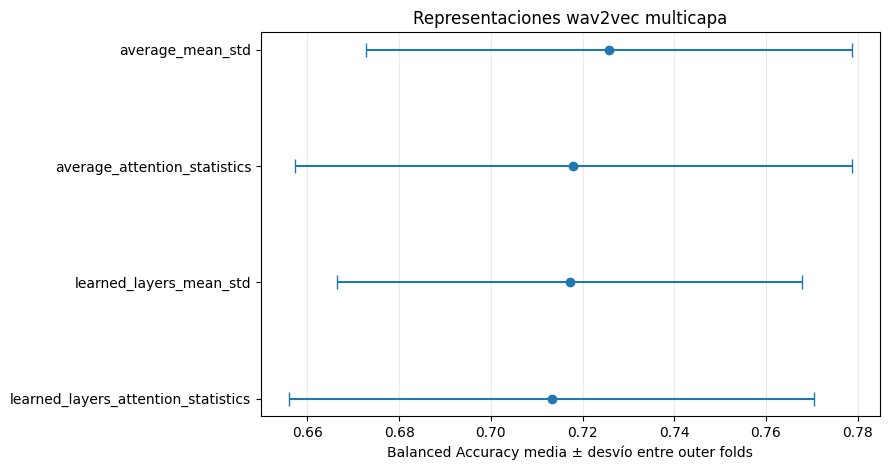

In [8]:
primary = primary_results()
if primary.empty:
    print("Sin resultados primarios para comparar.")
else:
    plot_data = (
        primary.groupby("refinement", observed=True)["balanced_accuracy"]
        .agg(["mean", "std"])
        .reindex([name for name in ACTIVE_CONFIGURATIONS if name in primary["refinement"].unique()])
        .dropna()
        .sort_values("mean")
    )
    fig, ax = plt.subplots(figsize=(9, 4.8))
    y = np.arange(len(plot_data))
    ax.errorbar(
        plot_data["mean"],
        y,
        xerr=plot_data["std"],
        fmt="o",
        capsize=5,
    )
    ax.set_yticks(y, plot_data.index)
    ax.set_xlabel("Balanced Accuracy media ± desvío entre outer folds")
    ax.set_title("Representaciones wav2vec multicapa")
    ax.grid(axis="x", alpha=.25)
    plt.tight_layout()
    plt.show()

## Figura 2 — Consistencia por outer fold y variabilidad entre semillas

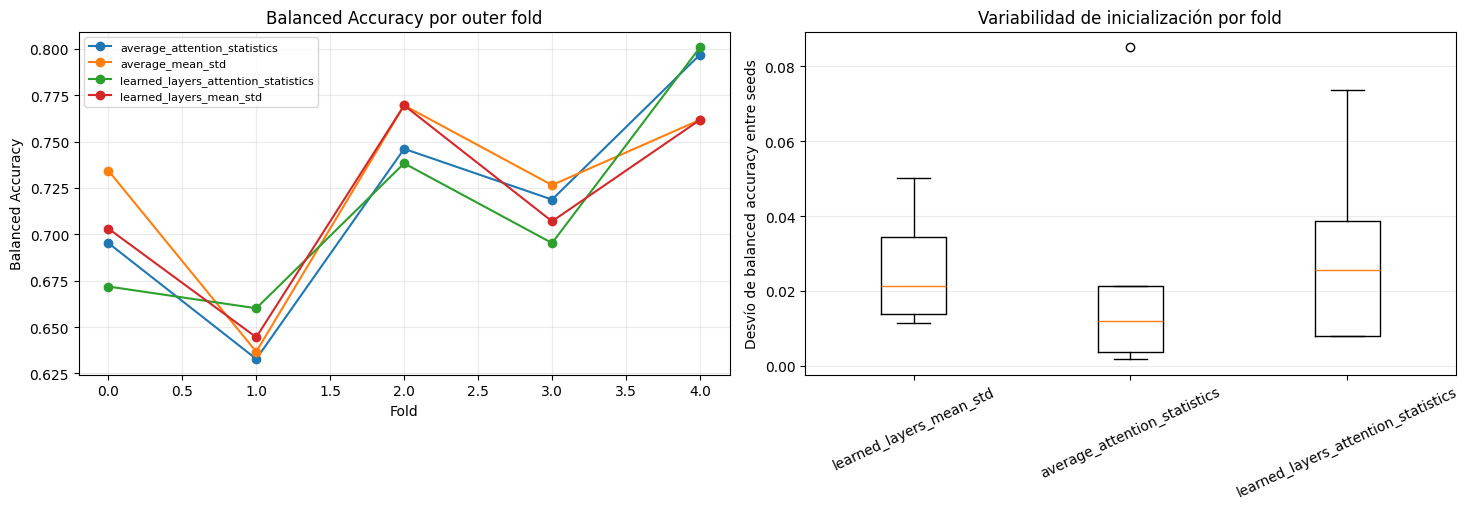

In [9]:
primary_all = primary_results(include_seed_rows=True)
if primary_all.empty:
    print("Sin resultados por fold.")
else:
    ensemble = primary_all.loc[
        ~primary_all.get(
            "result_type",
            pd.Series(index=primary_all.index, dtype=str),
        ).eq("seed")
    ]
    seed_rows = primary_all.loc[
        primary_all.get(
            "result_type",
            pd.Series(index=primary_all.index, dtype=str),
        ).eq("seed")
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

    for refinement, group in ensemble.groupby("refinement", observed=True):
        ordered = group.sort_values("fold")
        if ordered["fold"].nunique() != int(cfg.splits.cv_folds):
            continue
        axes[0].plot(
            ordered["fold"],
            ordered["balanced_accuracy"],
            marker="o",
            label=refinement,
        )
    axes[0].set_title("Balanced Accuracy por outer fold")
    axes[0].set_xlabel("Fold")
    axes[0].set_ylabel("Balanced Accuracy")
    axes[0].grid(alpha=.25)
    axes[0].legend(fontsize=8)

    attention_seed = seed_rows.loc[
        seed_rows["refinement"].isin(
            [
                "learned_layers_mean_std",
                "average_attention_statistics",
                "learned_layers_attention_statistics",
            ]
        )
    ]
    if attention_seed.empty:
        axes[1].text(
            .5,
            .5,
            "Sin resultados por seed",
            ha="center",
            va="center",
        )
        axes[1].set_axis_off()
    else:
        seed_summary = (
            attention_seed.groupby(
                ["refinement", "fold"],
                observed=True,
            )["balanced_accuracy"]
            .std(ddof=0)
            .reset_index(name="seed_std")
        )
        order = [
            name
            for name in ACTIVE_CONFIGURATIONS
            if name in seed_summary["refinement"].unique()
        ]
        values = [
            seed_summary.loc[
                seed_summary["refinement"] == name,
                "seed_std",
            ].to_numpy()
            for name in order
        ]
        axes[1].boxplot(values, tick_labels=order)
        axes[1].tick_params(axis="x", rotation=25)
        axes[1].set_ylabel("Desvío de balanced accuracy entre seeds")
        axes[1].set_title("Variabilidad de inicialización por fold")
        axes[1].grid(axis="y", alpha=.25)

    plt.tight_layout()
    plt.show()

## Figura 3 — Pesos aprendidos entre capas

Se comparan los pesos del pooling temporal uniforme (`learned_layers_mean_std`) con los del modelo que aprende simultáneamente capas y atención temporal.

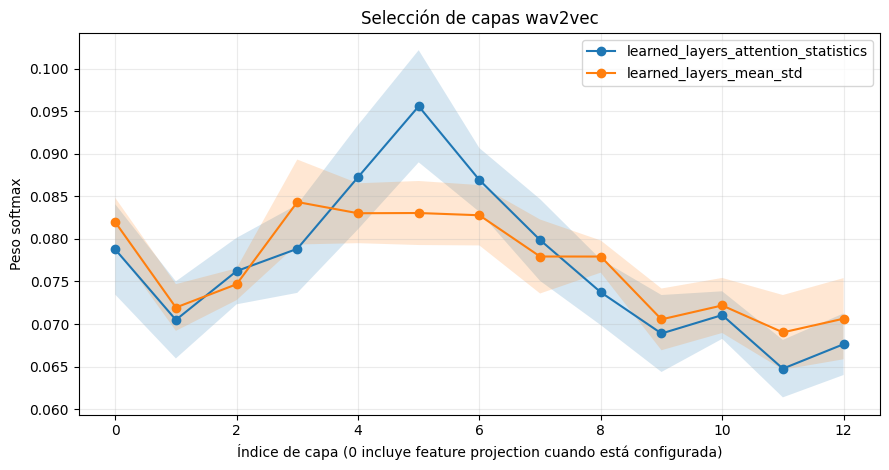

In [10]:
if layer_weights.empty:
    print("Sin pesos aprendidos de capas.")
else:
    subset = layer_weights.loc[
        (layer_weights["protocol"] == PROTOCOL_INDEPENDENT)
        & (layer_weights["target"] == TARGET_EMOTION_ORIGINAL)
        & (
            layer_weights["configuration"].isin(
                [
                    "learned_layers_mean_std",
                    "learned_layers_attention_statistics",
                ]
            )
        )
    ]
    if subset.empty:
        print("No están disponibles ambas configuraciones con pesos aprendidos.")
    else:
        fig, ax = plt.subplots(figsize=(9, 4.8))
        for configuration, group in subset.groupby(
            "configuration",
            observed=True,
        ):
            curve = group.groupby("layer", observed=True)["weight"].agg(
                ["mean", "std"]
            )
            x = curve.index.to_numpy()
            ax.plot(
                x,
                curve["mean"],
                marker="o",
                label=configuration,
            )
            ax.fill_between(
                x,
                curve["mean"] - curve["std"].fillna(0),
                curve["mean"] + curve["std"].fillna(0),
                alpha=.18,
            )
        ax.set_xlabel(
            "Índice de capa "
            "(0 incluye feature projection cuando está configurada)"
        )
        ax.set_ylabel("Peso softmax")
        ax.set_title("Selección de capas wav2vec")
        ax.legend()
        ax.grid(alpha=.25)
        plt.tight_layout()
        plt.show()

## Figura 4 — Concentración de la atención temporal

La entropía normalizada próxima a uno indica una distribución temporal difusa. Un máximo elevado o una fracción pequeña de frames para acumular el 50% de la masa indica atención concentrada.

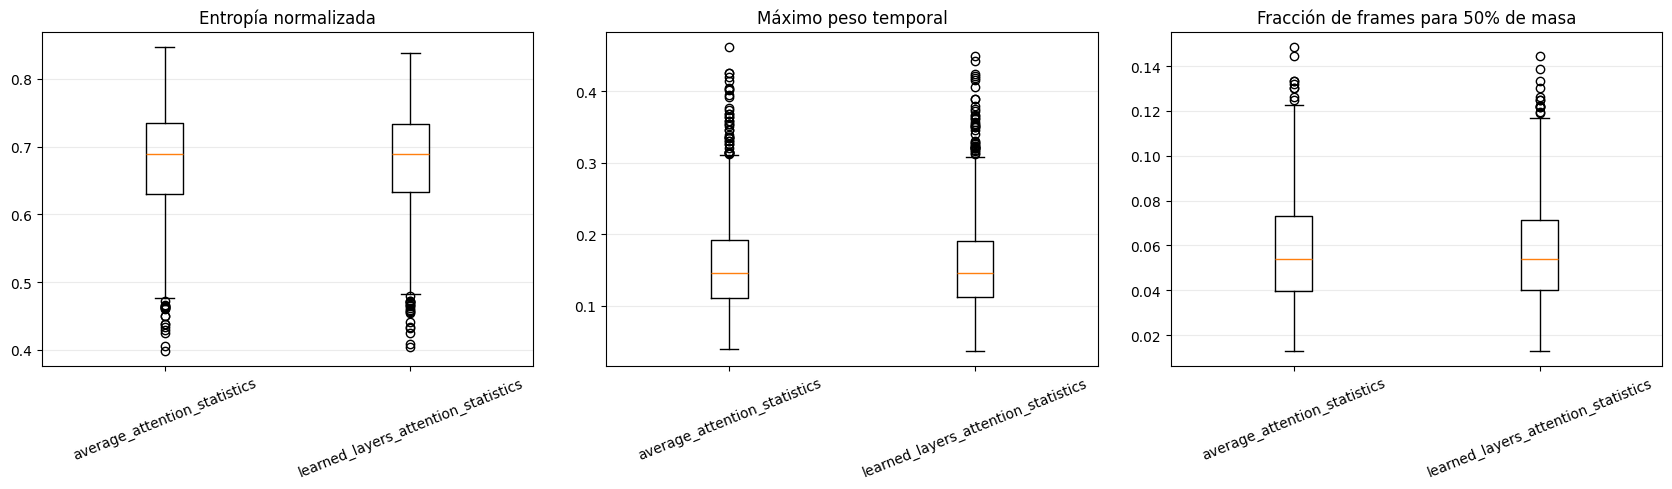

In [11]:
if attention_diagnostics.empty:
    print("Sin diagnósticos de atención.")
else:
    diagnostic_subset = attention_diagnostics.loc[
        (attention_diagnostics["protocol"] == PROTOCOL_INDEPENDENT)
        & (attention_diagnostics["target"] == TARGET_EMOTION_ORIGINAL)
        & (attention_diagnostics["seed"] == -1)
        & (
            attention_diagnostics["configuration"].isin(
                [
                    "average_attention_statistics",
                    "learned_layers_attention_statistics",
                ]
            )
        )
    ]
    if diagnostic_subset.empty:
        print("Sin diagnósticos ensemble para los modelos de atención.")
    else:
        metrics_to_plot = [
            (
                "attention_entropy_normalized",
                "Entropía normalizada",
            ),
            (
                "max_attention",
                "Máximo peso temporal",
            ),
            (
                "frames_fraction_50pct_mass",
                "Fracción de frames para 50% de masa",
            ),
        ]
        configurations = [
            name
            for name in [
                "average_attention_statistics",
                "learned_layers_attention_statistics",
            ]
            if name in diagnostic_subset["configuration"].unique()
        ]
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        for ax, (column, title) in zip(axes, metrics_to_plot):
            values = [
                diagnostic_subset.loc[
                    diagnostic_subset["configuration"] == name,
                    column,
                ].to_numpy()
                for name in configurations
            ]
            ax.boxplot(values, tick_labels=configurations)
            ax.tick_params(axis="x", rotation=22)
            ax.set_title(title)
            ax.grid(axis="y", alpha=.25)
        plt.tight_layout()
        plt.show()

## Figura 5 — Matrices OOF normalizadas

La comparación usa `average_mean_std` como referencia y selecciona el mejor modelo de atención por macro F1 medio. La tercera matriz muestra el cambio atención − baseline.

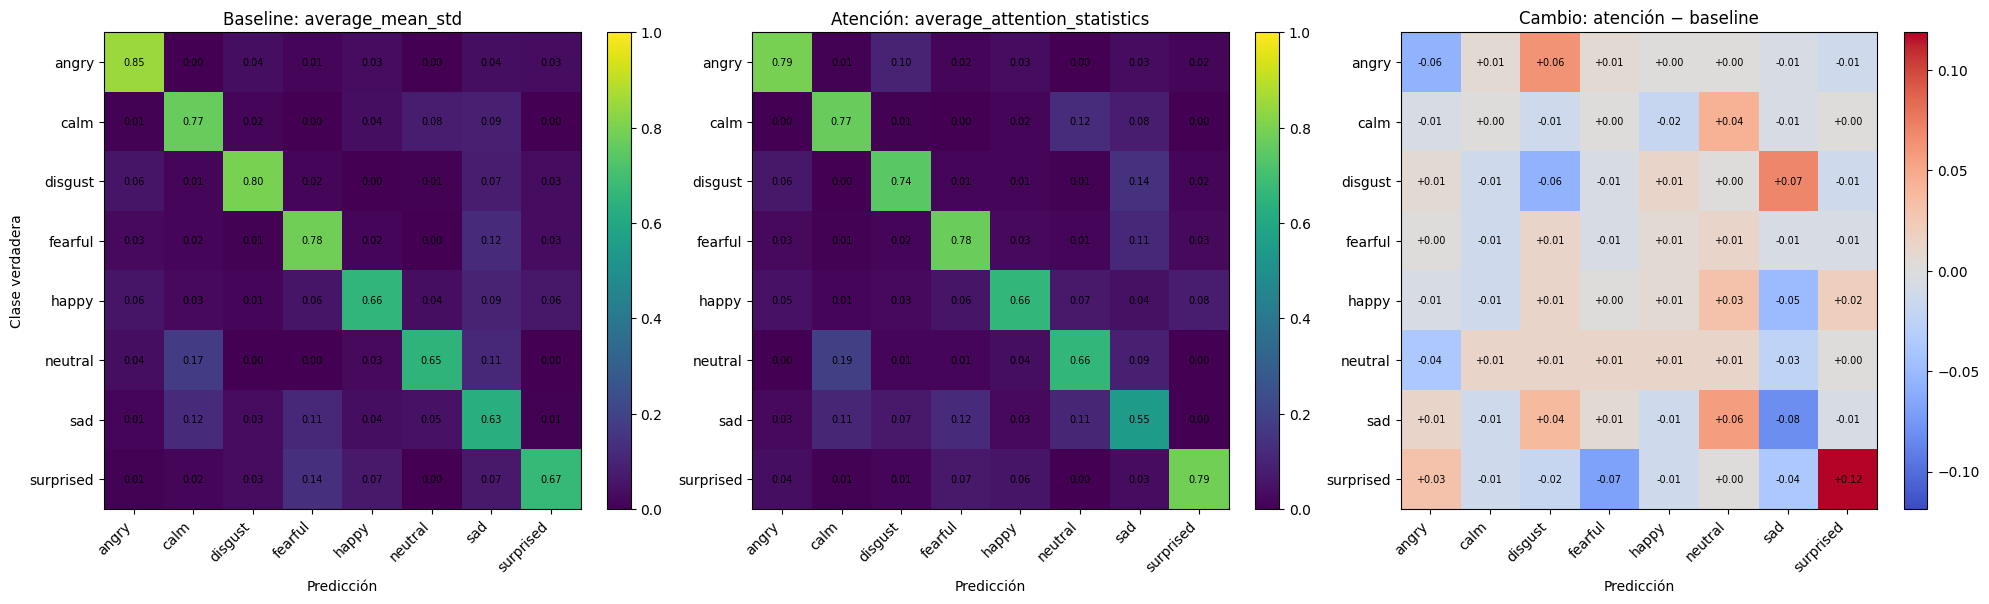

In [12]:
LABELS = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised",
]

primary = primary_results()
attention_candidates = (
    primary.loc[
        primary["refinement"].isin(
            [
                "average_attention_statistics",
                "learned_layers_attention_statistics",
            ]
        )
    ]
    if not primary.empty
    else pd.DataFrame()
)

if (
    oof_predictions.empty
    or attention_candidates.empty
    or not (primary["refinement"] == "average_mean_std").any()
):
    print("Predicciones OOF insuficientes para matrices comparativas.")
else:
    best_attention = (
        attention_candidates.groupby(
            "refinement",
            observed=True,
        )["balanced_accuracy"]
        .mean()
        .idxmax()
    )

    def select_predictions(refinement: str) -> pd.DataFrame:
        return oof_predictions.loc[
            (oof_predictions["protocol"] == PROTOCOL_INDEPENDENT)
            & (oof_predictions["target"] == TARGET_EMOTION_ORIGINAL)
            & (oof_predictions["refinement"] == refinement)
        ]

    baseline_pred = select_predictions("average_mean_std")
    attention_pred = select_predictions(best_attention)

    if baseline_pred.empty or attention_pred.empty:
        print("Faltan predicciones completas para la comparación.")
    else:
        cm_base = confusion_matrix(
            baseline_pred["y_true"],
            baseline_pred["y_pred"],
            labels=LABELS,
            normalize="true",
        )
        cm_attention = confusion_matrix(
            attention_pred["y_true"],
            attention_pred["y_pred"],
            labels=LABELS,
            normalize="true",
        )
        matrices = [
            cm_base,
            cm_attention,
            cm_attention - cm_base,
        ]
        titles = [
            "Baseline: average_mean_std",
            f"Atención: {best_attention}",
            "Cambio: atención − baseline",
        ]

        fig, axes = plt.subplots(1, 3, figsize=(20, 5.8))
        for index, (ax, matrix, title) in enumerate(
            zip(axes, matrices, titles)
        ):
            differential = index == 2
            limit = max(float(np.abs(matrix).max()), 1e-6)
            image = ax.imshow(
                matrix,
                cmap="coolwarm" if differential else "viridis",
                vmin=-limit if differential else 0,
                vmax=limit if differential else 1,
            )
            for row in range(len(LABELS)):
                for col in range(len(LABELS)):
                    text = (
                        f"{matrix[row, col]:+.2f}"
                        if differential
                        else f"{matrix[row, col]:.2f}"
                    )
                    ax.text(
                        col,
                        row,
                        text,
                        ha="center",
                        va="center",
                        fontsize=7,
                    )
            ax.set_xticks(
                range(len(LABELS)),
                LABELS,
                rotation=45,
                ha="right",
            )
            ax.set_yticks(range(len(LABELS)), LABELS)
            ax.set_title(title)
            ax.set_xlabel("Predicción")
            if index == 0:
                ax.set_ylabel("Clase verdadera")
            fig.colorbar(image, ax=ax, fraction=.046)

        plt.tight_layout()
        plt.show()

## Figura 6 — Atención temporal en ejemplos OOF

Se muestran como máximo tres casos: un error corregido, un acierto compartido y un error persistente. La atención se contrasta con RMS normalizado únicamente como referencia visual, sin atribución causal.

C:\Users\franc\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


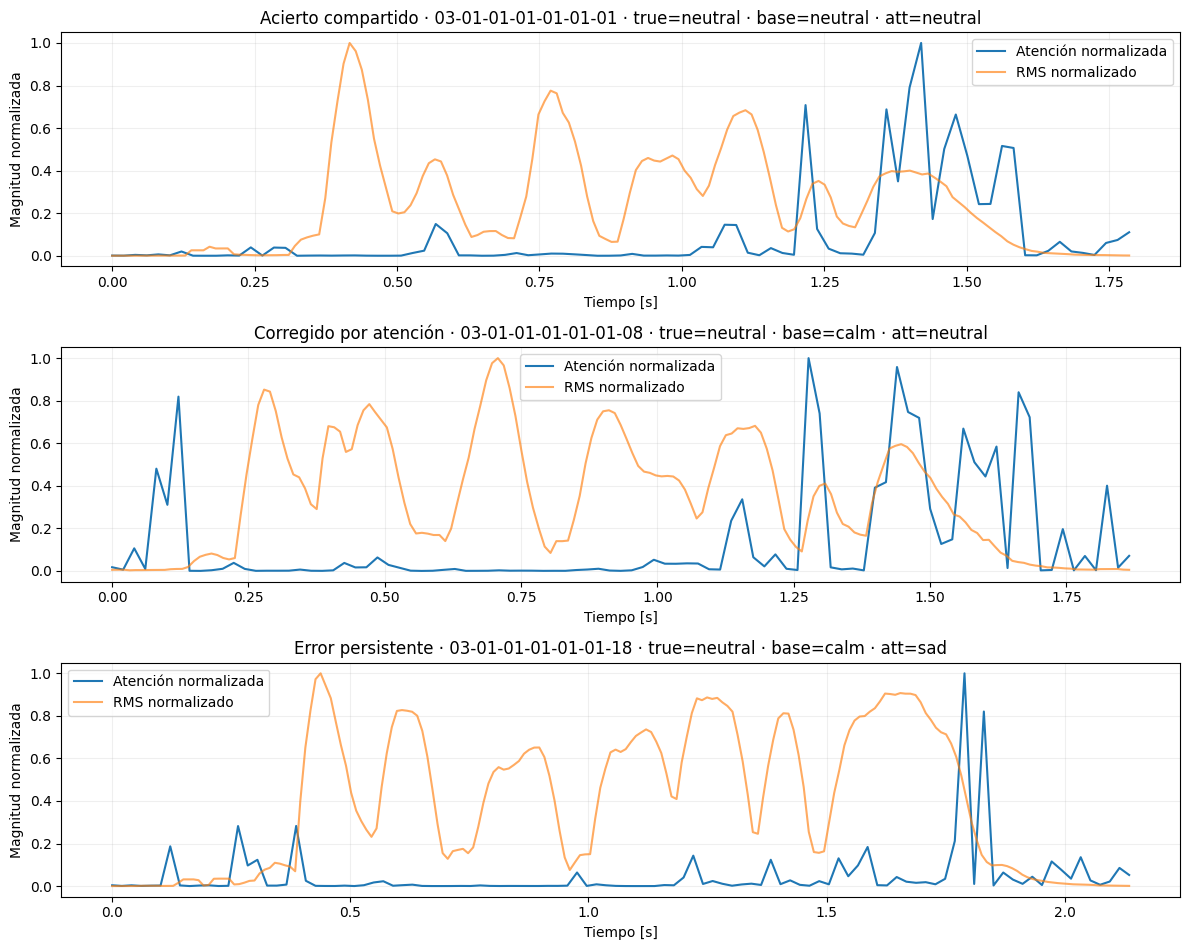

In [13]:
primary = primary_results()
attention_candidates = (
    primary.loc[
        primary["refinement"].isin(
            [
                "average_attention_statistics",
                "learned_layers_attention_statistics",
            ]
        )
    ]
    if not primary.empty
    else pd.DataFrame()
)

if (
    not attention_weight_map
    or oof_predictions.empty
    or attention_candidates.empty
):
    print("Sin pesos o predicciones de atención para visualizar ejemplos.")
else:
    best_attention = (
        attention_candidates.groupby(
            "refinement",
            observed=True,
        )["balanced_accuracy"]
        .mean()
        .idxmax()
    )
    baseline_pred = oof_predictions.loc[
        (oof_predictions["protocol"] == PROTOCOL_INDEPENDENT)
        & (oof_predictions["target"] == TARGET_EMOTION_ORIGINAL)
        & (oof_predictions["refinement"] == "average_mean_std")
    ]
    attention_pred = oof_predictions.loc[
        (oof_predictions["protocol"] == PROTOCOL_INDEPENDENT)
        & (oof_predictions["target"] == TARGET_EMOTION_ORIGINAL)
        & (oof_predictions["refinement"] == best_attention)
    ]

    comparison = baseline_pred[
        ["file_id", "y_true", "y_pred"]
    ].merge(
        attention_pred[["file_id", "y_pred"]],
        on="file_id",
        suffixes=("_base", "_att"),
    )
    comparison["case"] = np.select(
        [
            (
                comparison["y_pred_base"] != comparison["y_true"]
            )
            & (
                comparison["y_pred_att"] == comparison["y_true"]
            ),
            (
                comparison["y_pred_base"] == comparison["y_true"]
            )
            & (
                comparison["y_pred_att"] == comparison["y_true"]
            ),
        ],
        ["Corregido por atención", "Acierto compartido"],
        default="Error persistente",
    )

    available = comparison.loc[
        comparison["file_id"].astype(str).map(
            lambda file_id: (
                f"{best_attention}::{file_id}"
                in attention_weight_map
            )
        )
    ]
    chosen = (
        available.groupby("case", observed=True)
        .head(1)
        .head(3)
    )

    if chosen.empty:
        print("No se encontraron ejemplos alineados con pesos guardados.")
    else:
        meta_index = metadata.set_index("file_id")
        fig, axes = plt.subplots(
            len(chosen),
            1,
            figsize=(12, 3.2 * len(chosen)),
            squeeze=False,
        )
        for ax, (_, row) in zip(axes[:, 0], chosen.iterrows()):
            file_id = str(row["file_id"])
            weights = attention_weight_map[
                f"{best_attention}::{file_id}"
            ]
            duration = float(
                meta_index.loc[file_id, "duration_trimmed_s"]
            )
            time = np.linspace(0, duration, len(weights))
            ax.plot(
                time,
                weights / max(weights.max(), 1e-8),
                label="Atención normalizada",
            )

            audio_path = resolve_path(
                meta_index.loc[file_id, "file_path_trimmed"]
            )
            if audio_path.exists():
                import librosa

                waveform, _ = librosa.load(
                    audio_path,
                    sr=None,
                    mono=True,
                )
                rms = librosa.feature.rms(y=waveform)[0]
                rms_time = np.linspace(0, duration, len(rms))
                ax.plot(
                    rms_time,
                    rms / max(rms.max(), 1e-8),
                    alpha=.65,
                    label="RMS normalizado",
                )

            ax.set_title(
                f"{row['case']} · {file_id} · "
                f"true={row['y_true']} · "
                f"base={row['y_pred_base']} · "
                f"att={row['y_pred_att']}"
            )
            ax.set_xlabel("Tiempo [s]")
            ax.set_ylabel("Magnitud normalizada")
            ax.legend()
            ax.grid(alpha=.2)

        plt.tight_layout()
        plt.show()

## Figura final — Síntesis de rendimiento, estabilidad y complejidad

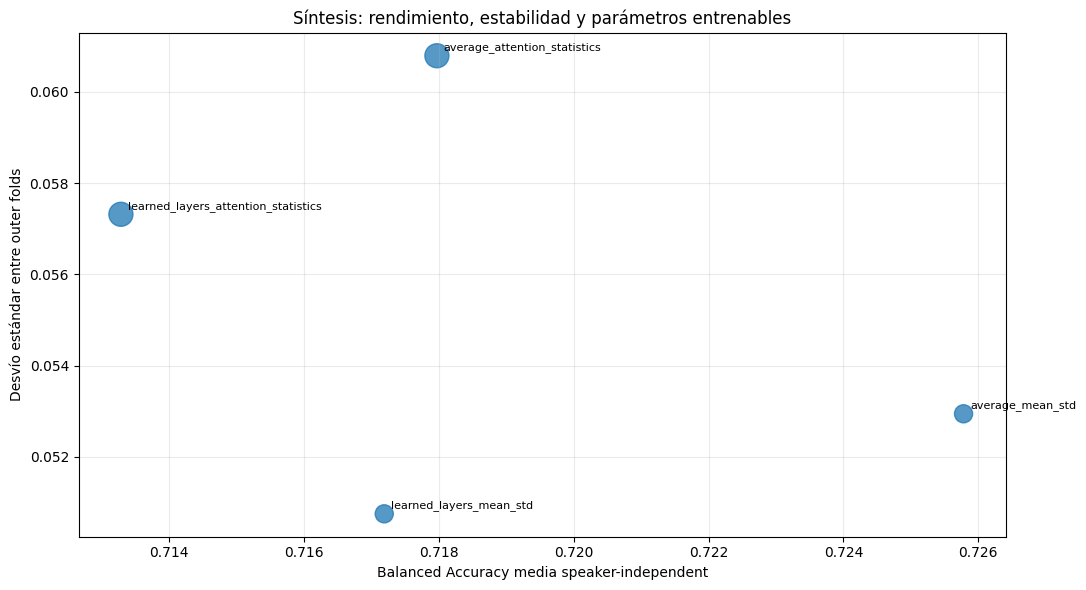

Candidato principal: average_mean_std · balanced_accuracy=0.726 ± 0.053 · peor fold=0.637


In [14]:
primary = primary_results()
if primary.empty:
    print("Sin resultados para la síntesis.")
else:
    if "trainable_params" not in primary.columns:
        primary["trainable_params"] = np.nan
    synthesis = (
        primary.groupby(
            ["representation", "model", "refinement"],
            observed=True,
        )
        .agg(
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            balanced_accuracy_std=("balanced_accuracy", "std"),
            worst_fold=("balanced_accuracy", "min"),
            n_features=("n_features", "mean"),
            trainable_params=("trainable_params", "mean"),
        )
        .reset_index()
    )
    synthesis["trainable_params"] = synthesis[
        "trainable_params"
    ].fillna(
        synthesis["n_features"] * len(LABELS)
    )
    max_params = max(float(synthesis["trainable_params"].max()), 1.0)
    sizes = 70 + 230 * np.sqrt(
        synthesis["trainable_params"] / max_params
    )

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.scatter(
        synthesis["balanced_accuracy_mean"],
        synthesis["balanced_accuracy_std"],
        s=sizes,
        alpha=.75,
    )
    for _, row in synthesis.iterrows():
        ax.annotate(
            row["refinement"],
            (
                row["balanced_accuracy_mean"],
                row["balanced_accuracy_std"],
            ),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_xlabel("Balanced Accuracy media speaker-independent")
    ax.set_ylabel("Desvío estándar entre outer folds")
    ax.set_title(
        "Síntesis: rendimiento, estabilidad y parámetros entrenables"
    )
    ax.grid(alpha=.25)
    plt.tight_layout()
    plt.show()

    ranked = synthesis.sort_values(
        ["balanced_accuracy_mean", "balanced_accuracy_std"],
        ascending=[False, True],
    )
    best = ranked.iloc[0]
    print(
        f"Candidato principal: {best['refinement']} · "
        f"balanced_accuracy={best['balanced_accuracy_mean']:.3f} ± "
        f"{best['balanced_accuracy_std']:.3f} · "
        f"peor fold={best['worst_fold']:.3f}"
    )

## Criterio de cierre

Una configuración de atención reemplaza a `average_mean_std` cuando:

- mejora al menos `0.01` de macro F1 medio, o mantiene una diferencia menor a `0.01` y reduce al menos `20%` el desvío entre folds;
- no degrada ningún outer fold más de `0.03`;
- mantiene un desvío medio entre seeds inferior a `0.02`.

Cuando `average_attention_statistics` y `learned_layers_attention_statistics` difieren menos de `0.01`, se elige la variante uniforme por simplicidad.

El resultado del notebook debe resolver una sola decisión: si la mejor representación SSL permanece en estadísticas multicapa estáticas o si la selección temporal aprendida agrega evidencia robusta antes de avanzar hacia la rama CNN-LSTM sobre log-Mel.